<a href="https://colab.research.google.com/github/wdohoon/wdohoon/blob/main/ex04)_%EB%94%A5%EB%9F%AC%EB%8B%9D_%EC%86%90%EA%B8%80%EC%94%A8_%EC%9D%B4%EB%AF%B8%EC%A7%80_%EB%8D%B0%EC%9D%B4%ED%84%B0_%EB%B6%84%EB%A5%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 목표
- 0 ~ 9까지의 손글씨 이미지 데이터를 분류하는 신경망 모델을 만들어보자!

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#
# mnist(Modified National institute of Standards and Technology), NIST : 미국표준기술연구소
from tensorflow.keras.datasets import mnist

In [ ]:
data = mnist.load_data()

11490434/11490434 [==============================] - 0s 0us/step


In [ ]:
len(data)

2

In [ ]:
data

((array([[[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         ...,
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0

In [ ]:
(X_train, y_train), (X_test, y_test) = data

In [ ]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

# 이미지라는 2차원 데이터를 다루기 때문에 shape의 형태는 3칸이 나오게됨
# (데이터의 수, 세로픽셀수, 가로픽셀)

((60000, 28, 28), (10000, 28, 28), (60000,), (10000,))

In [ ]:
y_train

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

In [ ]:
X_train

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

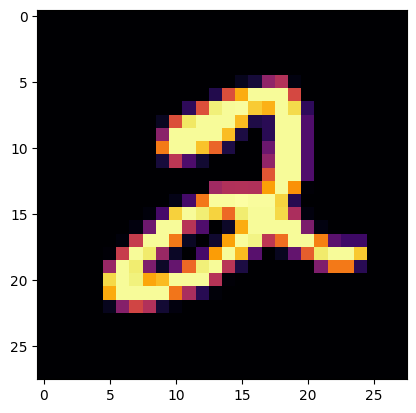

In [ ]:
# imshow : 이미지 데이터를 그림으로 출력해주는 함수
# cmap='gray' : 이미지를 흑백으로 전환시켜주는 인
plt.imshow(X_train[5], cmap='inferno')

In [ ]:
print(X_train[59999])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  38  48
   48  22   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0  62  97 198 243 254
  254 212  27   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0  67 172 254 25

### 정답 데이터 원핫인코딩
- pd.get_dummies : 판다스 지원 원핫인코딩
- to_categorical : keras에서 지원 원핫인코딩

In [ ]:
pd.get_dummies(y_train)

,0,1,2,3,4,5,6,7,8,9
0,0,0,0,0,0,1,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0
2,0,0,0,0,1,0,0,0,0,0
3,0,1,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...
59995,0,0,0,0,0,0,0,0,1,0
59996,0,0,0,1,0,0,0,0,0,0
59997,0,0,0,0,0,1,0,0,0,0
59998,0,0,0,0,0,0,1,0,0,0


In [ ]:
from tensorflow.keras.utils import to_categorical

In [ ]:
to_categorical(y_train)

array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.]], dtype=float32)

In [ ]:
y_train_one_hot = to_categorical(y_train)
y_test_one_hot = to_categorical(y_test)

In [ ]:
y_train_one_hot.shape, y_test_one_hot.shape

((60000, 10), (10000, 10))

- 인공신경망에는 2차원인 이미지데이터를 한 번에 넣을 수 없기 때문에 데이터의 차원을 전부 1차원으로 변경시켜준 뒤 학습시켜야함!

In [ ]:
X_train.shape

(60000, 28, 28)

In [ ]:
X_train = X_train.reshape(60000, -1)
X_test = X_test.reshape(10000, -1)

In [ ]:
X_train.shape, X_test.shape
# 이미지는 픽셀 하나하나가 데이터의 특성으로 인식됨

((60000, 784), (10000, 784))

### 신경망 모델링
- 직접 모델링해 봅시다~!

In [ ]:
# 입력되는 특성 수
# 출력층 활성화함수, 뉴런수
# loss함수
# 최적화함수(Adam, SGD 둘 다 사용해보기)

In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
# 1. 신경망 구조 설계
model = Sequential()

# 입력층 + 중간층 1개(Dense)
model.add(Dense(100, input_dim=784 , activation='sigmoid'))

# 중간층
model.add(Dense(75, activation='sigmoid'))
model.add(Dense(50, activation='sigmoid')) # 하나의 층
model.add(Dense(25, activation='sigmoid')) # 하나의 층

# 출력층은 정답의 개수(0~9)
model.add(Dense(10, activation='sigmoid'))

model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_10 (Dense)            (None, 100)               78500     
                                                                 
 dense_11 (Dense)            (None, 75)                7575      
                                                                 
 dense_12 (Dense)            (None, 50)                3800      
                                                                 
 dense_13 (Dense)            (None, 25)                1275      
                                                                 
 dense_14 (Dense)            (None, 10)                260       
                                                                 
Total params: 91,410
Trainable params: 91,410
Non-trainable params: 0
_________________________________________________________________


In [ ]:
model.compile(loss='categorical_crossentropy',
              optimizer='Adam',   # Adam : 최근에 가장 많이 사용되는 성능이 좋은 최적화함수
              metrics=['acc']    # metrics : 평가방법을 설정(분류 문제이므로 정확도 출력 필요)
              )

In [ ]:
h = model.fit(X_train, y_train_one_hot,
              epochs=30,
              batch_size=128   # 한번에 학습되는 데이터의 개수(디폴트 32개)
              verbose=1        # 학습 결과의 출력 형태 결정(0 : 출력X, 1: bar형태(디폴트), 2: bar없이 출력)
              )

Epoch 1/30
469/469 [==============================] - 4s 7ms/step - loss: 0.1536 - acc: 0.9521
Epoch 2/30
469/469 [==============================] - 3s 6ms/step - loss: 0.1489 - acc: 0.9536
Epoch 3/30
469/469 [==============================] - 2s 5ms/step - loss: 0.1480 - acc: 0.9540
Epoch 4/30
469/469 [==============================] - 3s 5ms/step - loss: 0.1394 - acc: 0.9570
Epoch 5/30
469/469 [==============================] - 2s 4ms/step - loss: 0.1410 - acc: 0.9564
Epoch 6/30
469/469 [==============================] - 2s 4ms/step - loss: 0.1440 - acc: 0.9553
Epoch 7/30
469/469 [==============================] - 2s 4ms/step - loss: 0.1426 - acc: 0.9552
Epoch 8/30
469/469 [==============================] - 2s 4ms/step - loss: 0.1369 - acc: 0.9580
Epoch 9/30
469/469 [==============================] - 2s 4ms/step - loss: 0.1419 - acc: 0.9555
Epoch 10/30
469/469 [==============================] - 2s 5ms/step - loss: 0.1397 - acc: 0.9560
Epoch 11/30
469/469 [============================

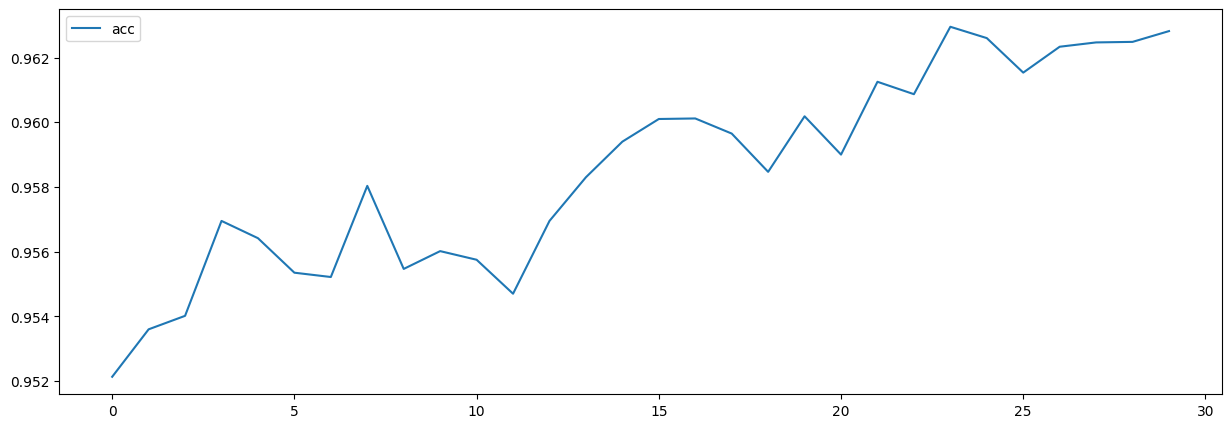

In [ ]:
# 3. 시각화
plt.figure(figsize=(15,5))

plt.plot(h.history['acc'],label='acc')

plt.legend()
plt.show()

In [ ]:
# 4. 모델평가
model.evaluate(X_test, y_test_one_hot)

313/313 [==============================] - 1s 2ms/step - loss: 0.1378 - acc: 0.9582


[0.13783152401447296, 0.9581999778747559]

### 과대적합을 확인하기 위해 train데이터에서 validation데이터를 분리해서 학습시 같이 출력해보자!

In [ ]:
# 무조건 train, test만 나눠주는게 아니라 데이터를 일정 비율로 랜덤하게 나눠주는 기능을 갖고 있음
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_val, y_train_one_hot, y_val_one_hot = train_test_split(X_train, y_train_one_hot,
                                                                  random_state=33
                                                                  )

In [ ]:
X_train.shape, X_val.shape, y_train_one_hot.shape, y_val_one_hot.shape

((45000, 784), (15000, 784), (45000, 10), (15000, 10))

In [ ]:
model2 = Sequential()

model2.add(Dense(200, input_dim = 784, activation = 'sigmoid'))
model2.add(Dense(400, activation = 'sigmoid'))
model2.add(Dense(200, activation = 'sigmoid'))
model2.add(Dense(100, activation = 'sigmoid'))
model2.add(Dense(50, activation = 'sigmoid'))
model2.add(Dense(10, activation = 'sigmoid'))

model2.add(Dense(10, activation = 'softmax'))

model2.summary()

model2.compile(loss = 'categorical_crossentropy',
              optimizer = 'Adam',
              metrics = ['acc']
              )

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_15 (Dense)            (None, 200)               157000    
                                                                 
 dense_16 (Dense)            (None, 400)               80400     
                                                                 
 dense_17 (Dense)            (None, 200)               80200     
                                                                 
 dense_18 (Dense)            (None, 100)               20100     
                                                                 
 dense_19 (Dense)            (None, 50)                5050      
                                                                 
 dense_20 (Dense)            (None, 10)                510       
                                                                 
 dense_21 (Dense)            (None, 10)               

In [ ]:
h2 = model2.fit(X_train, y_train_one_hot,
                epochs = 30,
                batch_size = 128,
                validation_data=(X_val, y_val_one_hot) # 검증용 데이터셋 추가
                )

Epoch 1/30
352/352 [==============================] - 2s 6ms/step - loss: 0.1194 - acc: 0.9630 - val_loss: 0.1648 - val_acc: 0.9507
Epoch 2/30
352/352 [==============================] - 2s 5ms/step - loss: 0.1198 - acc: 0.9640 - val_loss: 0.1569 - val_acc: 0.9538
Epoch 3/30
352/352 [==============================] - 2s 5ms/step - loss: 0.1175 - acc: 0.9644 - val_loss: 0.1523 - val_acc: 0.9549
Epoch 4/30
352/352 [==============================] - 2s 5ms/step - loss: 0.1238 - acc: 0.9612 - val_loss: 0.1519 - val_acc: 0.9539
Epoch 5/30
352/352 [==============================] - 2s 7ms/step - loss: 0.1095 - acc: 0.9657 - val_loss: 0.1475 - val_acc: 0.9573
Epoch 6/30
352/352 [==============================] - 3s 7ms/step - loss: 0.1089 - acc: 0.9658 - val_loss: 0.1453 - val_acc: 0.9571
Epoch 7/30
352/352 [==============================] - 2s 5ms/step - loss: 0.1074 - acc: 0.9674 - val_loss: 0.1490 - val_acc: 0.9563
Epoch 8/30
352/352 [==============================] - 2s 5ms/step - loss: 0.

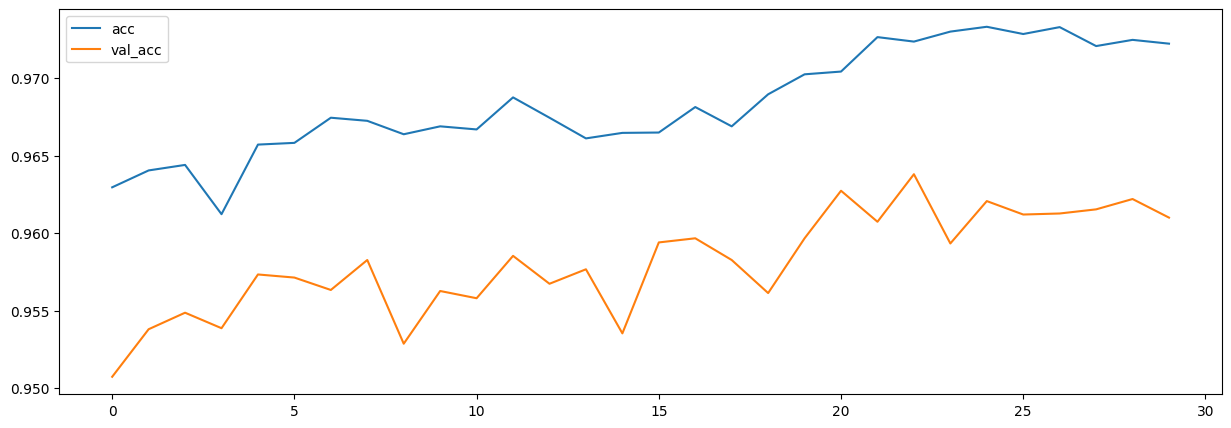

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(h2.history['acc'], label = 'acc')
plt.plot(h2.history['val_acc'], label='val_acc')
plt.legend()
plt.show()